# Percolação Explosiva em Redes Complexas

Aluno: Samuel de Oliveira Gamito - samuel.gamito@alumni.usp.br

### Emergência, robustez e cascatas — SME5924 (Redes Complexas), ICMC-USP

Este notebook investiga a **percolação explosiva**: o fenômeno em que uma regra *competitiva* de adição de arestas suprime sistematicamente o crescimento das componentes grandes, adiando a emergência da componente gigante até que ela surja de forma abrupta, numa janela de densidade que encolhe com o tamanho da rede.

**Observável central.** Toda a análise gira em torno de uma única grandeza, o *parâmetro de ordem*
$$ S = \frac{|C_{\max}|}{N}, $$
onde $|C_{\max}|$ é o número de nós da maior componente conexa e $N$ é o total de nós. Mediremos $S$ em três regimes que são três faces do mesmo fenômeno:


**Roteiro.**
0. Fundação — o observável $S$, a estrutura `DSU`, validação.
1. Percolação clássica (Erdős–Rényi) como *baseline* contínuo.
2. Percolação explosiva (processo de Achlioptas).
3. A transição é descontínua? — janela $\Delta$ e *finite-size scaling*.
4. A topologia importa — percolação sobre ER / BA / WS.
5. Robustez e ataques — a destruição do gigante.
6. Motter–Lai — cascatas de sobrecarga.
7. Síntese — primeira ordem vs. contínua.

## Seção 0 — Fundação

### Percolação, em uma frase
Percolação estuda como a *conectividade global* de um sistema emerge a partir de conexões *locais*. No nosso caso: partimos de $N$ nós isolados e inserimos arestas uma a uma e em algum momento surge uma componente conexa que abrange uma *fração finita* de todos os nós, a **componente gigante**. O parâmetro de ordem $S$ mede o tamanho relativo dessa componente e funciona como o análogo de uma fase ordenada em transições de fase.

### A ferramenta: *Disjoint Set Union* (Union–Find)
Para rastrear $|C_{\max}|$ a cada aresta adicionada **sem** recalcular as componentes do zero, usamos a estrutura **DSU**. Ela mantém os nós particionados em conjuntos disjuntos (as componentes) e oferece duas operações quase-constantes:

- `find(x)` — devolve o representante (raiz) da componente de `x`;
- `union(a, b)` — funde as componentes de `a` e `b`.



In [54]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import brentq
    

plt.rcParams.update({"figure.figsize": (7, 4.3), "axes.grid": True, "grid.alpha": 0.25})

In [55]:
class DSU:
    def __init__(self, n):
        self.parent = np.arange(n)
        self.size = np.ones(n, dtype=int)
        self.max_size = 1

    def find(self, x):
        root = x
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[x] != root:
            self.parent[x], x = root, self.parent[x]
        return root

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False
        if self.size[ra] < self.size[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        self.size[ra] += self.size[rb]
        if self.size[ra] > self.max_size:
            self.max_size = self.size[ra]
        return True

### Validação da `DSU`
Antes de confiar na estrutura, validamos contra um *oráculo*: construímos um grafo aleatório, inserimos suas arestas na `DSU` e conferimos que o maior conjunto coincide com a maior componente conexa calculada pelo NetworkX. Essa disciplina — *nunca confiar no código sem um teste independente* — se repete ao longo do notebook.

In [56]:
def largest_via_dsu(n, edges):
    dsu = DSU(n)
    for a, b in edges:
        dsu.union(int(a), int(b))
    return dsu.max_size

n = 5000
G = nx.gnm_random_graph(n, 4000, seed=7)
dsu_val = largest_via_dsu(n, G.edges())
nx_val = len(max(nx.connected_components(G), key=len))
print(f"|C_max|  DSU = {dsu_val}   NetworkX = {nx_val}   ->  {'OK' if dsu_val == nx_val else 'FALHA'}")

|C_max|  DSU = 3274   NetworkX = 3274   ->  OK


## Seção 1 — Percolação clássica de Erdős–Rényi

Antes da percolação *explosiva*, precisamos de um **baseline**: o processo clássico de Erdős–Rényi (ER), em que as arestas são adicionadas de forma puramente aleatória. Ele fornece uma transição de fase contínua e bem compreendida, contra a qual o caráter "explosivo" da Seção 2 vai contrastar.

### O processo
Partindo de $N$ nós isolados, a cada passo sorteamos dois nós uniformemente e os conectamos. Após $M$ arestas, definimos o tempo $t = M/N$; o grau médio da rede é $\langle k \rangle = 2M/N = 2t$ (cada aresta soma 2 ao total de graus).

### O resultado clássico
A componente gigante emerge num **limiar** preciso: $\langle k \rangle = 1$, isto é, $t_c = 1/2$. Abaixo dele só há componentes de tamanho $O(\log N)$ e $S \to 0$; acima, surge uma componente de tamanho $O(N)$ e $S > 0$. A fração do gigante satisfaz a equação transcendental
$$ S = 1 - e^{-\langle k \rangle S} = 1 - e^{-2tS}, $$
que resolveremos numericamente para traçar a curva teórica.

> **Convenção do processo.** Sorteamos pares *com reposição*, então self-loops ($a=b$) e arestas repetidas podem ocorrer. Ambos são *no-ops* na `DSU` — é a versão *multigrafo* do ER, padrão na literatura de percolação. O efeito sobre o eixo $t$ é $O(1/N)$ e desaparece para $N$ grande, como a validação confirma.

### Por que é o baseline certo
A transição do ER é **contínua** (segunda ordem): $S$ cresce a partir de zero de forma suave logo após $t_c$. Guarde essa imagem — a percolação explosiva vai produzir uma curva que *parece* saltar, e a Seção 3 medirá exatamente o quanto.

In [57]:
def erdos_renyi(n, steps, rng):
    dsu = DSU(n)
    cmax = np.empty(steps, dtype=int)
    for i in range(steps):
        dsu.union(rng.integers(n), rng.integers(n))
        cmax[i] = dsu.max_size
    return cmax

### A curva de emergência
Rodamos o processo até $t = 1.2$ (ou seja, $1.2N$ arestas) e normalizamos $S = |C_{\max}|/N$ apenas para plotar, conforme a convenção da Seção 0.

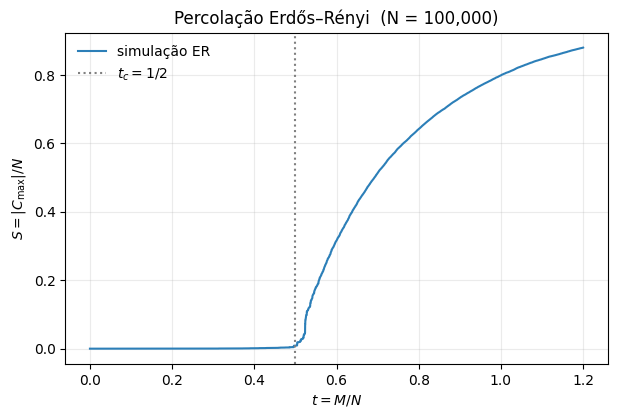

In [58]:
n = 100_000
cmax_er = erdos_renyi(n, int(1.2 * n), np.random.default_rng(1))
t = np.arange(1, len(cmax_er) + 1) / n
S_er = cmax_er / n

fig, ax = plt.subplots()
ax.plot(t, S_er, lw=1.5, color="#2c7fb8", label="simulação ER")
ax.axvline(0.5, color="gray", ls=":", label=r"$t_c = 1/2$")
ax.set_xlabel(r"$t = M/N$"); ax.set_ylabel(r"$S = |C_{\max}|/N$")
ax.set_title(f"Percolação Erdős–Rényi  (N = {n:,})")
ax.legend(frameon=False); plt.show()

### Validação contra a teoria
A prova de que nosso processo *segue o modelo* ER é sobrepor a curva simulada à solução de $S = 1 - e^{-2tS}$. Resolvemos a equação ponto a ponto com `brentq` (para $\langle k \rangle = 2t \le 1$ o único ponto fixo é $S=0$; acima, há a raiz não-trivial).

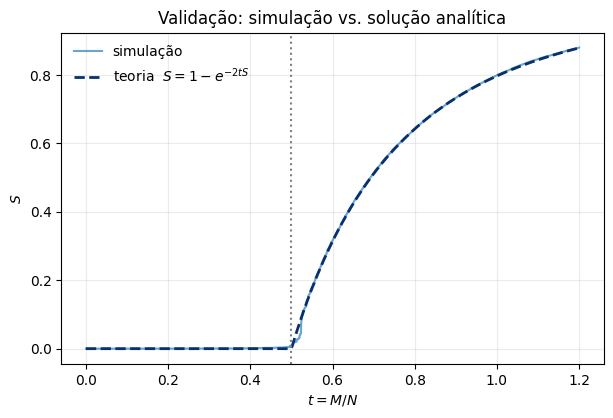

erro maximo |sim - teoria| = 0.0425  (concentrado na regiao critica)


In [59]:
def S_teorico_er(t):
    c = 2 * t                                  # grau medio
    if c <= 1:
        return 0.0
    return brentq(lambda S: 1 - np.exp(-c * S) - S, 1e-9, 1.0)

t_grid = np.linspace(0, 1.2, 400)
S_grid = np.array([S_teorico_er(x) for x in t_grid])

fig, ax = plt.subplots()
ax.plot(t, S_er, lw=1.5, alpha=0.7, color="#2c7fb8", label="simulação")
ax.plot(t_grid, S_grid, "--", lw=2, color="#08306b", label=r"teoria  $S = 1 - e^{-2tS}$")
ax.axvline(0.5, color="gray", ls=":")
ax.set_xlabel(r"$t = M/N$"); ax.set_ylabel(r"$S$")
ax.set_title("Validação: simulação vs. solução analítica")
ax.legend(frameon=False); plt.show()

erro = max(abs(S_er[i] - S_teorico_er(t[i])) for i in range(0, len(t), 20))
print(f"erro maximo |sim - teoria| = {erro:.4f}  (concentrado na regiao critica)")

### Conclusão da Seção 1
A simulação cai sobre a curva teórica; o erro residual concentra-se em torno de $t_c$ e é o *borrão de tamanho finito* esperado e ele encolhe conforme $N$ cresce. Estabelecemos assim a referência de que uma transição **contínua**, com gigante emergindo suavemente em $t_c = 1/2$.

## Seção 2 — Percolação explosiva (processo de Achlioptas)

No ER, cada aresta é aceita sem critério. Achlioptas, D'Souza e Spencer (*Science*, 2009) introduziram **competição**: a cada passo sorteamos **duas** arestas candidatas e adicionamos apenas a que mantém as componentes menores. Na *product rule*, comparamos o **produto dos tamanhos** das componentes que cada candidata uniria e escolhemos a de menor produto:
$$ \text{escolher } e \in \{e_1, e_2\} \text{ que minimiza } |C(u)| \cdot |C(v)|. $$
Minimizar o produto privilegia fundir componentes pequenas e **penaliza** o crescimento das grandes. O gigante é sistematicamente sufocado até que não há mais como adiá-lo.

### Por que "explosivo"
Adiar a emergência faz acumular muitas componentes de tamanho médio. Quando o gigante finalmente se forma, ele o faz absorvendo essas componentes quase de uma vez — um salto abrupto em $S$, em torno de $t_c \approx 0.888$, bem além do $t_c = 0.5$ do ER.


In [60]:
def achlioptas(n, steps, rng):
    dsu = DSU(n)
    cmax = np.empty(steps, dtype=int)
    for i in range(steps):
        a1, b1, a2, b2 = rng.integers(n, size=4)
        p1 = dsu.size[dsu.find(a1)] * dsu.size[dsu.find(b1)]
        p2 = dsu.size[dsu.find(a2)] * dsu.size[dsu.find(b2)]
        dsu.union(a1, b1) if p1 <= p2 else dsu.union(a2, b2)
        cmax[i] = dsu.max_size
    return cmax

### Clássica vs. explosiva
Rodamos a product rule no mesmo $N$ e eixo $t$ da Seção 1 e sobrepomos as duas curvas. O contraste é o resultado central da Seção.

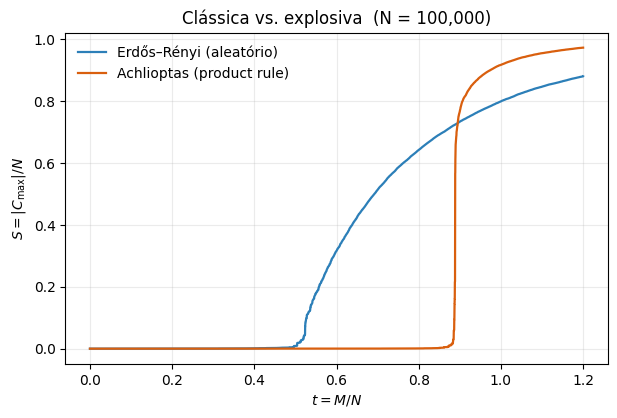

ER cruza S=0.5 em t=0.692
Achlioptas cruza S=0.5 em t=0.889


In [61]:
cmax_ap = achlioptas(n, int(1.2 * n), np.random.default_rng(1))
S_ap = cmax_ap / n

fig, ax = plt.subplots()
ax.plot(t, S_er, lw=1.6, color="#2c7fb8", label="Erdős–Rényi (aleatório)")
ax.plot(t, S_ap, lw=1.6, color="#d95f0e", label="Achlioptas (product rule)")
ax.set_xlabel(r"$t = M/N$"); ax.set_ylabel(r"$S = |C_{\max}|/N$")
ax.set_title(f"Clássica vs. explosiva  (N = {n:,})")
ax.legend(frameon=False); plt.show()

t_meio = t[np.searchsorted(cmax_ap, n / 2, "right")]
print(f"ER cruza S=0.5 em t={t[np.searchsorted(cmax_er, n/2, 'right')]:.3f}")
print(f"Achlioptas cruza S=0.5 em t={t_meio:.3f}")

### Leitura da figura
O ER (azul) sobe suave a partir de $t_c = 0.5$. A explosiva (laranja) permanece **suprimida** perto de zero por muito mais tempo e então dispara quase na vertical perto de $t \approx 0.888$. Visualmente, parece uma transição **descontínua** com um salto de $S \approx 0$ para $S \approx 1$ numa janela minúscula.

## Seção 3 — A transição é mesmo descontínua?

Esta é a seção central do trabalho. Para decidir entre transição de primeira ordem (descontínua) e contínua (mesmo que íngreme), precisamos **quantificar a largura da transição** e ver como ela escala com o tamanho da rede.

### Os marcos $t_0$ e $t_1$
Seguindo Achlioptas–D'Souza–Spencer, acompanhamos o tamanho **absoluto** $|C_{\max}|$ e definimos dois instantes:

- $t_0$ — o último instante em que $|C_{\max}|$ ainda é *pequena*, convencionalmente $< \sqrt{N}$;
- $t_1$ — o primeiro instante em que $|C_{\max}|$ já é *macroscópica*, $> N/2$.

A **janela de transição** é o intervalo entre eles. Medimos em duas unidades:
$$ W = (\text{passo em } t_1) - (\text{passo em } t_0) \quad\text{(em arestas)}, \qquad \Delta = \frac{W}{N} \quad\text{(em } t = M/N\text{)}. $$

### O critério: linear vs. sublinear
Ajustamos $W \sim N^{\alpha}$:

- Se $\alpha = 1$ (**linear**), então $\Delta = W/N \to$ constante: a janela tem largura finita em $t$ — transição **contínua**. *(caso ER)*
- Se $\alpha < 1$ (**sublinear**), então $\Delta = W/N \to 0$: a janela some em $t$ — *aparência* de salto. *(caso Achlioptas)*

"Sublinear" significa exatamente isto: $W$ cresce mais devagar que $N$, logo $W/N \to 0$.

In [62]:
def window(cmax, n):
    step0 = np.searchsorted(cmax, np.sqrt(n), "left")   # 1o passo com |C| >= sqrt(N)
    step1 = np.searchsorted(cmax, n / 2, "right")        # 1o passo com |C| > N/2
    W = step1 - step0
    return W, W / n

### Finite-size scaling
Computamos $W$ e $\Delta$ para uma faixa de $N$, promediando sobre várias realizações para reduzir o ruído da região crítica. **Esta é a célula mais pesada do notebook** (roda Achlioptas várias vezes para $N$ grande); reduza `Ns` ou `runs` se precisar de velocidade.

In [63]:
def janela_media(processo, n, runs, seed=0):
    Ws, Ds = [], []
    for k in range(runs):
        cmax = processo(n, int(1.1 * n), np.random.default_rng(seed + k))
        W, D = window(cmax, n)
        Ws.append(W); Ds.append(D)
    return np.mean(Ws), np.mean(Ds)

Ns = np.array([1000, 3000, 10000, 30000, 100000])
runs = 4
W_er = np.array([janela_media(erdos_renyi, int(N), runs)[0] for N in Ns])
W_ap = np.array([janela_media(achlioptas, int(N), runs)[0] for N in Ns])
D_er, D_ap = W_er / Ns, W_ap / Ns

alpha_er = np.polyfit(np.log(Ns), np.log(W_er), 1)[0]
alpha_ap = np.polyfit(np.log(Ns), np.log(W_ap), 1)[0]
print(f"W ~ N^alpha:   ER alpha = {alpha_er:.2f} (linear ~ 1)   |   Achlioptas alpha = {alpha_ap:.2f} (sublinear < 1)")

W ~ N^alpha:   ER alpha = 0.94 (linear ~ 1)   |   Achlioptas alpha = 0.65 (sublinear < 1)


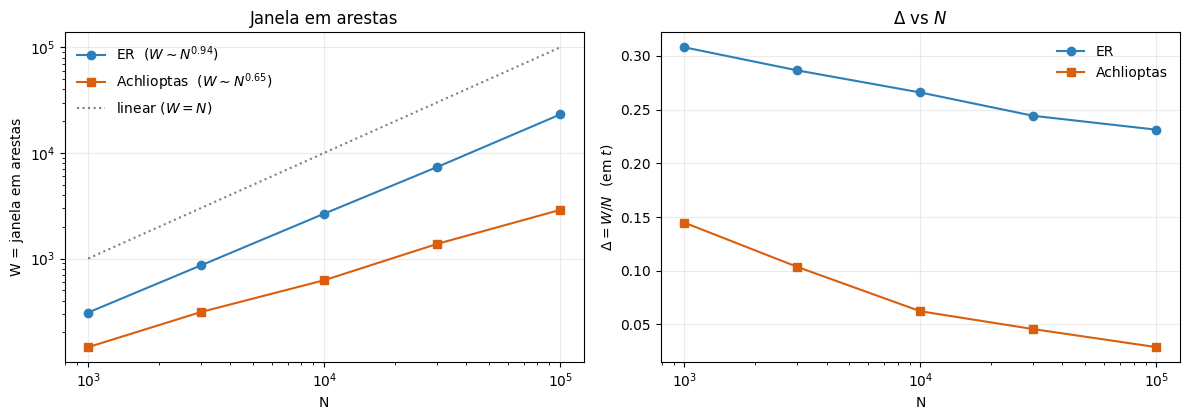

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.loglog(Ns, W_er, "o-", color="#2c7fb8", label=rf"ER  ($W\sim N^{{{alpha_er:.2f}}}$)")
ax1.loglog(Ns, W_ap, "s-", color="#d95f0e", label=rf"Achlioptas  ($W\sim N^{{{alpha_ap:.2f}}}$)")
ax1.loglog(Ns, Ns, "k:", alpha=0.5, label="linear ($W = N$)")
ax1.set_xlabel("N"); ax1.set_ylabel("W = janela em arestas")
ax1.set_title("Janela em arestas"); ax1.legend(frameon=False)

ax2.semilogx(Ns, D_er, "o-", color="#2c7fb8", label="ER")
ax2.semilogx(Ns, D_ap, "s-", color="#d95f0e", label="Achlioptas")
ax2.set_xlabel("N"); ax2.set_ylabel(r"$\Delta = W/N$  (em $t$)")
ax2.set_title(r"$\Delta$ vs $N$"); ax2.legend(frameon=False)
fig.tight_layout(); plt.show()

### Explosiva **não é** descontínua
Os dados mostram o padrão esperado: o ER tem $\alpha \approx 1$ (a janela cresce junto com $N$, e $\Delta$ estabiliza num platô) enquanto a Achlioptas tem $\alpha \approx 0.65$ — **sublinear**, com $\Delta$ encolhendo em direção a zero.

A leitura da simulação diz "Achlioptas é descontínua". Mas há evidências teóricas do contrário:

- **da Costa et al. (2010)** mostraram que a transição da product rule é, no limite termodinâmico, **contínua**;
- **Riordan & Warnke (2011)** provaram *rigorosamente* que **todo** processo de Achlioptas (qualquer regra que escolha entre um número finito de arestas) tem transição contínua.

A aparência de descontinuidade vinha de efeitos de tamanho finito: a janela $\Delta \to 0$, mas o salto em $S$ **também** tende a zero no limite, só que muito devagar. O fenômeno tem expoentes críticos atípicos e é hoje classificado como uma transição contínua *anômala* (D'Souza–Nagler, 2015).

**Conclusão.** "Explosivo" descreve a abruptez numérica observável, que medimos via $\alpha < 1$ — e não uma descontinuidade verdadeira.

## Seção 4 — Percolação sobre diferentes topologias (ER, BA e WS )

Até aqui construímos redes a partir de nós isolados. Agora invertemos a pergunta: dada uma **topologia fixa** (aleatória, scale-free ou small-world), como o componente gigante emerge ao ativarmos suas arestas?


In [65]:
def barabasi_albert(n, m, rng):
    edges, repeated = [], []
    for src in range(m, n):
        if repeated:
            targets = set()
            while len(targets) < m:
                targets.add(repeated[rng.integers(len(repeated))])
        else:
            targets = set(range(m))
        edges.extend((src, t) for t in targets)
        repeated.extend(targets)
        repeated.extend([src] * m)
    return edges

def watts_strogatz(n, k, p, rng):
    adj = {i: set() for i in range(n)}
    for i in range(n):
        for j in range(1, k // 2 + 1):
            nb = (i + j) % n
            adj[i].add(nb); adj[nb].add(i)
    for i in range(n):
        for j in range(1, k // 2 + 1):
            nb = (i + j) % n
            if rng.random() < p:
                w = rng.integers(n)
                while w == i or w in adj[i]:
                    w = rng.integers(n)
                adj[i].discard(nb); adj[nb].discard(i)
                adj[i].add(w); adj[w].add(i)
    seen, edges = set(), []
    for i in adj:
        for j in adj[i]:
            e = (i, j) if i < j else (j, i)
            if e not in seen:
                seen.add(e); edges.append(e)
    return edges

### Validação dos geradores
Para o **BA**, o marco é o expoente de grau. Ajustá-lo via regressão log-log do histograma é enviesado; usamos o estimador de **máxima verossimilhança** (Clauset–Shalizi–Newman). A prova de fidelidade é o nosso gerador dar o *mesmo* expoente que o NetworkX. Para o **WS**, comparamos o clustering contra a teoria do anel, $C(0) = \frac{3(k-2)}{4(k-1)}$, e contra o NetworkX.

In [66]:
def gamma_mle(deg, kmin):
    x = deg[deg >= kmin]
    return 1 + len(x) / np.sum(np.log(x / (kmin - 0.5)))

# --- BA ---
n_ba, m = 50_000, 3
deg_meu = np.array([d for _, d in nx.from_edgelist(barabasi_albert(n_ba, m, np.random.default_rng(7))).degree()])
deg_nx = np.array([d for _, d in nx.barabasi_albert_graph(n_ba, m, seed=7).degree()])
print("BA  expoente (MLE, kmin=m):  meu = %.3f   networkx = %.3f   (cauda -> 3)" %
      (gamma_mle(deg_meu, m), gamma_mle(deg_nx, m)))

# --- WS ---
n_ws, k = 1000, 6
print("\nWS  clustering C(p):  C(0) teorico anel = %.3f" % (3*(k-2)/(4*(k-1))))
for p in [0.0, 0.1, 1.0]:
    c_meu = nx.average_clustering(nx.from_edgelist(watts_strogatz(n_ws, k, p, np.random.default_rng(7))))
    c_nx = nx.average_clustering(nx.watts_strogatz_graph(n_ws, k, p, seed=7))
    print(f"  p={p:<4} meu={c_meu:.3f}  networkx={c_nx:.3f}")

BA  expoente (MLE, kmin=m):  meu = 2.581   networkx = 2.584   (cauda -> 3)

WS  clustering C(p):  C(0) teorico anel = 0.600
  p=0.0  meu=0.600  networkx=0.600
  p=0.1  meu=0.436  networkx=0.437
  p=1.0  meu=0.004  networkx=0.004


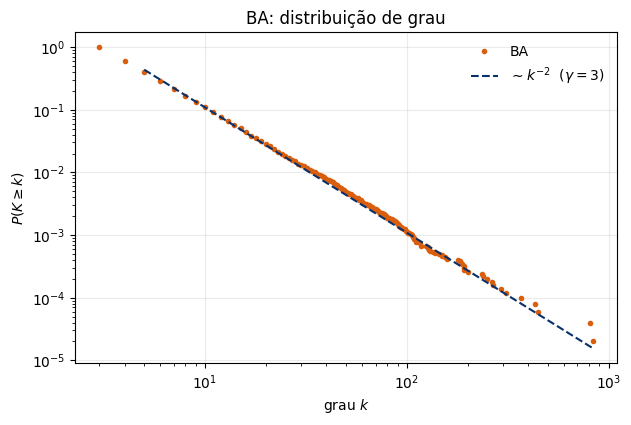

In [67]:
ks = np.sort(np.unique(deg_meu))
ccdf = np.array([(deg_meu >= kk).mean() for kk in ks])
ref = ks.astype(float) ** (-2.0)
ref *= ccdf[np.argmax(ks >= 10)] / ref[np.argmax(ks >= 10)]

fig, ax = plt.subplots()
ax.loglog(ks, ccdf, "o", ms=3, color="#d95f0e", label="BA")
ax.loglog(ks[ks >= 5], ref[ks >= 5], "--", color="#08306b", label=r"$\sim k^{-2}$  ($\gamma = 3$)")
ax.set_xlabel("grau $k$"); ax.set_ylabel(r"$P(K \geq k)$")
ax.set_title("BA: distribuição de grau"); ax.legend(frameon=False); plt.show()

### Percolação sobre as topologias
Para colocar BA/WS no mesmo gráfico de $S$ vs. tempo, *percolamos* sobre eles: embaralhamos as arestas do grafo e as ativamos uma a uma. A ordem aleatória é o que torna o processo uma percolação.

In [68]:
def percolate_topology(n, edges, rng):
    edges = np.asarray(edges)
    perm = rng.permutation(len(edges))
    dsu = DSU(n)
    cmax = np.empty(len(edges), dtype=int)
    for i, idx in enumerate(perm):
        a, b = edges[idx]
        dsu.union(int(a), int(b))
        cmax[i] = dsu.max_size
    return cmax

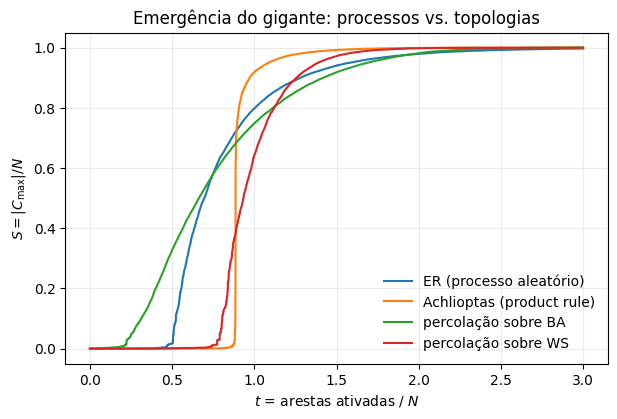

In [69]:
N = 50_000
seed = np.random.default_rng(1)
cmax_er2 = erdos_renyi(N, 3 * N, np.random.default_rng(1))
cmax_ap2 = achlioptas(N, 3 * N, np.random.default_rng(1))
cmax_ba = percolate_topology(N, barabasi_albert(N, 3, np.random.default_rng(1)), np.random.default_rng(2))
cmax_ws = percolate_topology(N, watts_strogatz(N, 6, 0.1, np.random.default_rng(1)), np.random.default_rng(2))

tax = lambda c: np.arange(1, len(c) + 1) / N
fig, ax = plt.subplots()
for c, lbl in [(cmax_er2, "ER (processo aleatório)"), (cmax_ap2, "Achlioptas (product rule)"),
               (cmax_ba, "percolação sobre BA"), (cmax_ws, "percolação sobre WS")]:
    ax.plot(tax(c), c / N, lw=1.5, label=lbl)
ax.set_xlabel(r"$t$ = arestas ativadas / $N$"); ax.set_ylabel(r"$S = |C_{\max}|/N$")
ax.set_title("Emergência do gigante: processos vs. topologias"); ax.legend(frameon=False); plt.show()


### Leitura
O **BA** forma o gigante quase imediatamente — limiar de percolação praticamente nulo. Os hubs unem a rede com pouquíssimas arestas. Esse é o **resultado de robustez scale-free** (Albert–Jeong–Barabási, 2000): redes heterogêneas resistem à falha aleatória porque o gigante já existe muito cedo.

## Seção 5 — Robustez e ataques: a destruição do gigante

Invertendo o processo das seções anteriores: em vez de *adicionar* conexões, **removemos nós** e medimos como o gigante se desfaz. Atacar é percolação ao contrário, o mesmo observável $S$, no sentido oposto.

### Duas estratégias de remoção
- **Falha aleatória** — remove nós uniformemente (avaria não intencional, ruído).
- **Ataque dirigido** — remove primeiro os nós de maior grau (sabotagem, dirigida aos hubs).

### O algoritmo: remoção-reversa
Remover nós quebra componentes, e a `DSU` só sabe *fundir*. O truque é processar a remoção **ao contrário**: partimos do grafo vazio e *adicionamos* os nós na ordem inversa da remoção, unindo cada um aos vizinhos já presentes. Isso recupera $|C_{\max}|$ a cada estágio em $O(M\,\alpha(N))$, e invertemos o resultado para obter $S$ vs. fração removida. *(Validamos esse algoritmo contra o NetworkX antes de usá-lo.)*

### A hipótese (Albert–Barabási, 2000)
Redes scale-free seriam **robustas a falhas** (poucos hubs, então remover ao acaso quase nunca os atinge) mas **frágeis a ataques** (remover os poucos hubs estilhaça a rede). Vamos verificar.

In [70]:
def build_adj(n, edges):
    adj = [[] for _ in range(n)]
    for a, b in edges:
        adj[a].append(b); adj[b].append(a)
    return adj

def robustness_curve(n, adj, order):
    """order = nos na ordem de REMOCAO. Reconstroi adicionando em ordem reversa.
    Retorna (fracao removida crescente, S = |C_max|/n)."""
    present = np.zeros(n, dtype=bool)
    dsu = DSU(n); dsu.max_size = 0
    giant = np.empty(n)
    for j, v in enumerate(reversed(order)):
        present[v] = True
        if dsu.max_size == 0:
            dsu.max_size = 1
        for u in adj[v]:
            if present[u]:
                dsu.union(v, u)
        giant[j] = dsu.max_size
    f_removed = (n - np.arange(1, n + 1)) / n
    return f_removed[::-1], (giant / n)[::-1]

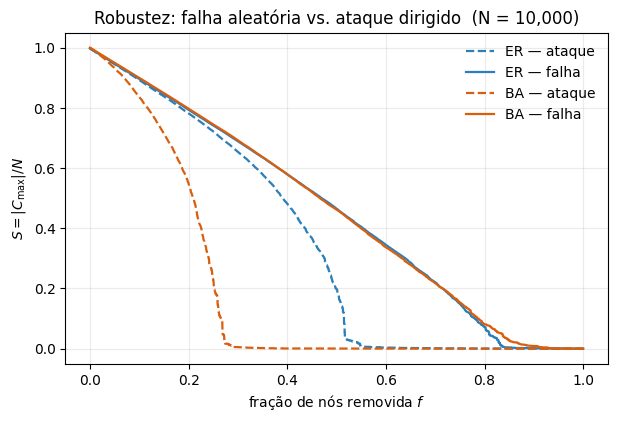

In [71]:
n_rob = 10_000
redes = {
    "ER": nx.gnm_random_graph(n_rob, 3 * n_rob, seed=1).edges(),
    "BA": barabasi_albert(n_rob, 3, np.random.default_rng(1)),
}
rng_fail = np.random.default_rng(0)
curvas = {}
for nome, edges in redes.items():
    adj = build_adj(n_rob, list(edges))
    grau = np.array([len(a) for a in adj])
    ordem_ataque = list(np.argsort(-grau))                 # maior grau primeiro
    ordem_falha = list(rng_fail.permutation(n_rob))        # aleatorio
    curvas[(nome, "ataque")] = robustness_curve(n_rob, adj, ordem_ataque)
    curvas[(nome, "falha")] = robustness_curve(n_rob, adj, ordem_falha)

fig, ax = plt.subplots()
estilo = {"ER": "#2c7fb8", "BA": "#d95f0e"}
for (nome, modo), (f, S) in curvas.items():
    ls = "-" if modo == "falha" else "--"
    ax.plot(f, S, ls, color=estilo[nome], lw=1.6, label=f"{nome} — {modo}")
ax.set_xlabel("fração de nós removida $f$"); ax.set_ylabel(r"$S = |C_{\max}|/N$")
ax.set_title(f"Robustez: falha aleatória vs. ataque dirigido  (N = {n_rob:,})")
ax.legend(frameon=False); plt.show()

### Leitura da figura
O padrão de Albert–Barabási aparece nítido:

- **BA sob falha aleatória** (linha cheia laranja) é o mais **robusto** — o gigante resiste mesmo removendo metade dos nós, porque o acaso quase nunca acerta os hubs.
- **BA sob ataque dirigido** (tracejado laranja) é o mais **frágil** — remover os poucos hubs colapsa a rede com uma fração pequena de remoções.
- O **ER** responde de forma parecida aos dois modos: sendo homogêneo, não há hubs privilegiados para mirar, então ataque e falha quase coincidem.

Essa assimetria é a marca das redes heterogêneas (Cohen 2000/2001; Callaway 2000; Holme 2002). A destruição aqui é **estática**: removemos nós e olhamos o estrago imediato. Falta o ingrediente *dinâmico* — o que acontece quando a remoção de um nó **sobrecarrega** os vizinhos e dispara uma reação em cadeia. É a Seção 6.

## Seção 6 — Motter–Lai: cascatas de sobrecarga

Nas redes reais (energia, tráfego, microsserviços), os nós carregam **fluxo**. Remover um nó não só desconecta — ele **redistribui carga** para os demais, que podem estourar sua capacidade e falhar em cadeia. O modelo de **Motter–Lai (2002)** captura isso.

### O modelo
- **Carga** $L_i$ = *betweenness* do nó $i$ (proxy do fluxo que passa por ele).
- **Capacidade** $C_i = (1+\alpha)\,L_i$, onde $\alpha \ge 0$ é a *tolerância* (margem de folga).
- **Gatilho**: removemos o nó de maior carga.
- **Cascata**: recalculamos a carga; todo nó com $L_i > C_i$ falha e é removido; repetimos até estabilizar.
- **Dano** $G = |C_{\max}'|/N$ — tamanho relativo do maior componente *após* a cascata.

### A previsão
Em redes heterogêneas, a carga se concentra nos hubs. Remover o hub de maior carga joga um fluxo enorme sobre poucos nós, propagando a falha. A previsão de Motter–Lai: **scale-free é mais vulnerável a cascatas** do que redes homogêneas, para a mesma tolerância $\alpha$.


In [72]:
def motter_lai_damage(G, alpha):
    G = G.copy(); n0 = G.number_of_nodes()
    load0 = nx.betweenness_centrality(G, normalized=False)
    capacity = {v: (1 + alpha) * load0[v] for v in G}
    G.remove_node(max(load0, key=load0.get))                 # gatilho: no de maior carga
    while True:
        load = nx.betweenness_centrality(G, normalized=False)
        over = [v for v in G if load[v] > capacity[v]]
        if not over:
            break
        G.remove_nodes_from(over)
    if G.number_of_nodes() == 0:
        return 0.0
    return len(max(nx.connected_components(G), key=len)) / n0

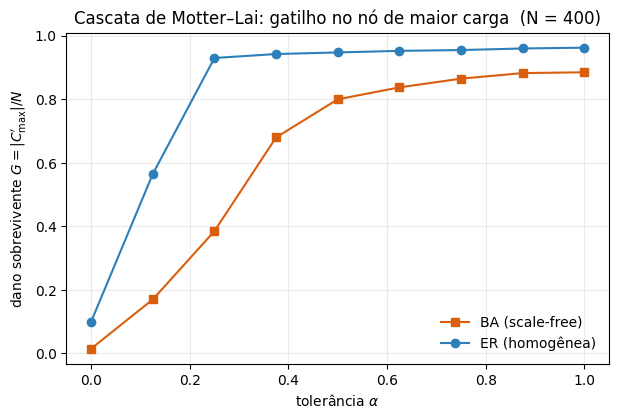

In [73]:
n_ml = 400
G_ba_ml = nx.from_edgelist(barabasi_albert(n_ml, 2, np.random.default_rng(3)))
G_er_ml = nx.gnm_random_graph(n_ml, G_ba_ml.number_of_edges(), seed=3)   # mesmo n de arestas

alphas = np.linspace(0.0, 1.0, 9)
dano_ba = np.array([motter_lai_damage(G_ba_ml, a) for a in alphas])
dano_er = np.array([motter_lai_damage(G_er_ml, a) for a in alphas])

fig, ax = plt.subplots()
ax.plot(alphas, dano_ba, "s-", color="#d95f0e", label="BA (scale-free)")
ax.plot(alphas, dano_er, "o-", color="#2c7fb8", label="ER (homogênea)")
ax.set_xlabel(r"tolerância $\alpha$"); ax.set_ylabel(r"dano sobrevivente $G = |C_{\max}'|/N$")
ax.set_title(f"Cascata de Motter–Lai: gatilho no nó de maior carga  (N = {n_ml})")
ax.legend(frameon=False); plt.show()

### Leitura da figura
A previsão se confirma. Para $\alpha$ pequeno (pouca folga), **ambas** colapsam já que qualquer redistribuição estoura capacidades. Mas no regime intermediário ($\alpha \approx 0.2$–$0.5$) a separação é dramática: o **BA** sofre dano muito maior (gigante menor) que o **ER** com a mesma tolerância. A heterogeneidade que tornava o BA robusto à *falha aleatória* (Seção 5) o torna **frágil à cascata dirigida**, ao remover o hub de maior carga concentra o fluxo e propaga a falha.

Estratégias de defesa (Motter, 2004; Crucitti 2004) exploram justamente isso: remover seletivamente nós de baixa carga *antes* da cascata pode, contraintuitivamente, *reduzir* o dano total.

## Seção 7 — Síntese

Todo o notebook girou em torno de um único observável, $S = |C_{\max}|/N$, medido em três regimes. A figura abaixo os reúne lado a lado.

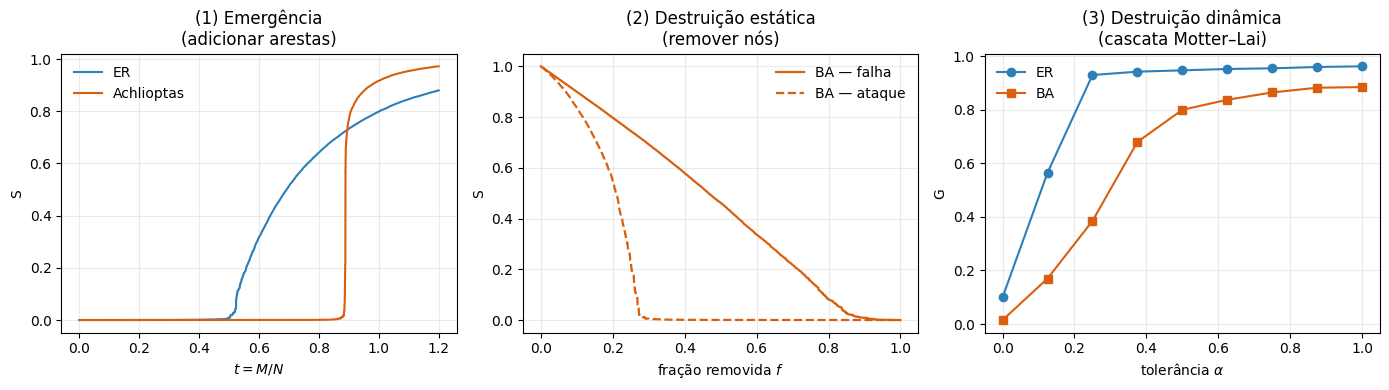

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (1) Emergencia (Secao 2)
axes[0].plot(t, S_er, color="#2c7fb8", lw=1.5, label="ER")
axes[0].plot(t, S_ap, color="#d95f0e", lw=1.5, label="Achlioptas")
axes[0].set_xlabel(r"$t = M/N$"); axes[0].set_ylabel("S")
axes[0].set_title("(1) Emergência\n(adicionar arestas)"); axes[0].legend(frameon=False)

# (2) Destruicao estatica (Secao 5)
f_ba_a, S_ba_a = curvas[("BA", "ataque")]
f_ba_f, S_ba_f = curvas[("BA", "falha")]
axes[1].plot(f_ba_f, S_ba_f, color="#d95f0e", lw=1.6, label="BA — falha")
axes[1].plot(f_ba_a, S_ba_a, "--", color="#d95f0e", lw=1.6, label="BA — ataque")
axes[1].set_xlabel("fração removida $f$"); axes[1].set_ylabel("S")
axes[1].set_title("(2) Destruição estática\n(remover nós)"); axes[1].legend(frameon=False)

# (3) Destruicao dinamica (Secao 6)
axes[2].plot(alphas, dano_er, "o-", color="#2c7fb8", label="ER")
axes[2].plot(alphas, dano_ba, "s-", color="#d95f0e", label="BA")
axes[2].set_xlabel(r"tolerância $\alpha$"); axes[2].set_ylabel("G")
axes[2].set_title("(3) Destruição dinâmica\n(cascata Motter–Lai)"); axes[2].legend(frameon=False)

fig.tight_layout(); plt.show()

### O eixo que une tudo: primeira ordem vs. contínua

Este trabalho começou com uma pergunta — *a percolação explosiva é descontínua?* — e a resposta organizou três temas:

1. **Emergência.** A product rule de Achlioptas *parece* produzir um salto, mas o finite-size scaling ($\Delta \sim N^{-0.35}$, janela sublinear) revela uma transição **contínua anômala** (da Costa 2010; Riordan–Warnke 2011), não de primeira ordem.
2. **Destruição estática.** A robustez de uma rede é a percolação ao contrário. Redes scale-free são *robustas-e-frágeis*: resistem à falha aleatória, colapsam sob ataque aos hubs (Albert–Barabási 2000).
3. **Destruição dinâmica.** Quando a carga redistribui (Motter–Lai 2002), a mesma heterogeneidade vira um passivo — cascatas dirigidas estilhaçam a rede.

**O fecho — primeira ordem de verdade.** Onde a "explosividade" deixa de ser aparência e vira uma transição *genuinamente* descontínua? Em **redes interdependentes** (Buldyrev et al., *Nature* 2010): quando duas redes dependem uma da outra, a cascata de falhas mútuas produz um colapso de **primeira ordem** real — um salto abrupto no limite termodinâmico, ao contrário da explosiva de uma rede única. É o elo conceitual que fecha o círculo: a transição que a percolação explosiva apenas *imita* existe de fato quando acoplamos as redes.

> **Extensão (pesquisa).** Grafos de dependência de microsserviços são exatamente o cenário Motter–Lai: carga = volume de requisições por serviço, capacidade = limite de throughput. A Seção 6, aplicada a uma topologia real extraída de observabilidade, prediz quais serviços, se sobrecarregados, disparam a maior cascata — uma ferramenta de análise de resiliência arquitetural.

## Referências

1. Achlioptas, D., D'Souza, R.M., Spencer, J. (2009). *Explosive percolation in random networks*. **Science** 323, 1453.
2. da Costa, R.A. et al. (2010). *Explosive percolation transition is actually continuous*. **PRL** 105, 255701.
3. Riordan, O., Warnke, L. (2011). *Explosive percolation is continuous*. **Science** 333, 322.
4. D'Souza, R.M., Nagler, J. (2015). *Anomalous critical and supercritical phenomena in explosive percolation*. **Nature Physics** 11, 531.
5. Barabási, A.-L., Albert, R. (1999). *Emergence of scaling in random networks*. **Science** 286, 509.
6. Watts, D.J., Strogatz, S.H. (1998). *Collective dynamics of 'small-world' networks*. **Nature** 393, 440.
7. Albert, R., Jeong, H., Barabási, A.-L. (2000). *Error and attack tolerance of complex networks*. **Nature** 406, 378.
8. Cohen, R. et al. (2000, 2001). *Resilience / Breakdown of the internet...*. **PRL** 85, 4626; 86, 3682.
9. Callaway, D.S. et al. (2000). *Network robustness and fragility*. **PRL** 85, 5468.
10. Holme, P. et al. (2002). *Attack vulnerability of complex networks*. **PRE** 65, 056109.
11. Motter, A.E., Lai, Y.-C. (2002). *Cascade-based attacks on complex networks*. **PRE** 66, 065102(R).
12. Motter, A.E. (2004). *Cascade control and defense in complex networks*. **PRL** 93, 098701.
13. Buldyrev, S.V. et al. (2010). *Catastrophic cascade of failures in interdependent networks*. **Nature** 464, 1025.
14. Clauset, A., Shalizi, C.R., Newman, M.E.J. (2009). *Power-law distributions in empirical data*. **SIAM Review** 51, 661.